# Bee YOLO-Pose baseline: исходная геометрия 512×512 + class-aware bbox

Эта версия фиксирует рабочее решение после отладки геометрии.

Ключевые решения:

- не используем sliding-window `640/480` в baseline;
- оставляем физические crop-ы `512×512`, как в исходной `.txt`-разметке;
- `YOLO_IMGSZ = 640` можно оставить: Ultralytics сам масштабирует изображения и labels при обучении;
- исходная разметка содержит `center + angle + source_class`, а не bbox;
- bbox строим искусственно, но теперь отдельно для целых и частичных пчёл;
- две keypoint-точки трактуем как голову/хвост после визуальной проверки: синяя — голова, красная — хвост;
- для частичных/круглых объектов keypoints отключены;
- ориентация оси тела считается как `angle + pi/2 + HEAD_TAIL_FLIP_RAD`.

Перед полной конвертацией обязательно запустить визуальную проверку `show_original_notebook_geometry()`: она должна показать овал/круг, bbox, центр и ось тела на одном исходном crop-е.


In [1]:
# Для Google Colab раскомментируйте при необходимости:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q ultralytics pandas pillow matplotlib pyyaml tqdm numpy

In [3]:
from __future__ import annotations

import math
import random
import shutil
from dataclasses import dataclass
from pathlib import Path
from typing import Literal

import numpy as np
import pandas as pd
import yaml
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from IPython.display import display, Image as IPyImage

import torch
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
print('Using device:', DEVICE)


CUDA available: True
GPU: Tesla T4
Using device: 0


## 1. Пути и параметры

Названия директорий оставлены такими же, как в твоём последнем ноутбуке.


In [4]:
PROJECT_DIR = Path('/content/drive/MyDrive/ITMO_NN_2')

EXTRACT_DIR = PROJECT_DIR / 'Data'
FRAMES_DIR = EXTRACT_DIR / 'frames'
ANNOTATIONS_DIR = EXTRACT_DIR / 'positions'

YOLO_DATASET_DIR = PROJECT_DIR / 'yolo_bees_pose_dataset'

SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# ВАЖНО: исходная txt-разметка привязана к crop-ам 512×512.
# Это не меняем для baseline.
SOURCE_CROP_SIZE = 512

# Размер входа YOLO. Картинки могут быть 512×512, а YOLO сам ресайзит их до 640×640.
YOLO_IMGSZ = 640

# Геометрия исходной debug-разметки.
# В первом ноутбуке полная пчела рисовалась эллипсом a=20, b=35,
# то есть базовая ширина 40 px, базовая длина 70 px.
ELLIPSE_HALF_WIDTH_PX = 20.0
ELLIPSE_HALF_LENGTH_PX = 35.0
PARTIAL_CIRCLE_RADIUS_PX = 20.0

# Раздувание bbox отдельно для целых и частичных пчёл.
# Для целых пчёл bbox вытянут вдоль продольной оси.
FULL_BBOX_LENGTH_SCALE = 1.95
FULL_BBOX_WIDTH_SCALE = 1.15

# Для частичных пчёл source_class == 2 используем компактный квадратный bbox вокруг круга.
PARTIAL_BBOX_SCALE = 1.15

# Длина линии/keypoints для целых пчёл. По умолчанию равна длине bbox целой пчелы.
FULL_AXIS_LENGTH_SCALE = FULL_BBOX_LENGTH_SCALE

# КРИТИЧНО: в исходной визуализации длинная ось эллипса соответствует angle + pi/2,
# поэтому линия ориентации должна строиться именно так, иначе она получится перпендикулярной.
BODY_AXIS_OFFSET_RAD = math.pi / 2

# По текущей визуальной проверке синяя точка соответствует голове, красная — хвосту.
# Поэтому разворачиваем направление на pi и задаём цвета явно.
HEAD_TAIL_FLIP_RAD = math.pi
HEAD_COLOR = (0, 100, 255)   # blue
TAIL_COLOR = (255, 0, 0)     # red
CENTER_COLOR = (255, 255, 255)
AXIS_COLOR = (255, 255, 0)
BBOX_COLOR = (0, 255, 0)

# Флаги запуска
RUN_ORIGINAL_GEOMETRY_CHECK = True
ORIGINAL_GEOMETRY_APPROVED = True  # после визуальной проверки поставить True

PREPARE_DATASET = False
TRAIN_MODEL = True
RUN_TEST_PREDICT = True

# Для быстрой проверки можно оставить 20 или 90. Для полного обучения поставить None.
MAX_FRAMES = 90

RUN_NAME = 'yolo_pose_bees_original_512_to_imgsz640_class_bbox_v3'
DATA_YAML = YOLO_DATASET_DIR / 'data.yaml'

print('PROJECT_DIR:', PROJECT_DIR)
print('FRAMES_DIR:', FRAMES_DIR)
print('ANNOTATIONS_DIR:', ANNOTATIONS_DIR)
print('YOLO_DATASET_DIR:', YOLO_DATASET_DIR)
print('SOURCE_CROP_SIZE:', SOURCE_CROP_SIZE)
print('YOLO_IMGSZ:', YOLO_IMGSZ)
print('FULL bbox length/width:',
      2 * ELLIPSE_HALF_LENGTH_PX * FULL_BBOX_LENGTH_SCALE,
      2 * ELLIPSE_HALF_WIDTH_PX * FULL_BBOX_WIDTH_SCALE)
print('PARTIAL bbox size:',
      2 * PARTIAL_CIRCLE_RADIUS_PX * PARTIAL_BBOX_SCALE)
print('HEAD_TAIL_FLIP_RAD:', HEAD_TAIL_FLIP_RAD)


PROJECT_DIR: /content/drive/MyDrive/ITMO_NN_2
FRAMES_DIR: /content/drive/MyDrive/ITMO_NN_2/Data/frames
ANNOTATIONS_DIR: /content/drive/MyDrive/ITMO_NN_2/Data/positions
YOLO_DATASET_DIR: /content/drive/MyDrive/ITMO_NN_2/yolo_bees_pose_dataset
SOURCE_CROP_SIZE: 512
YOLO_IMGSZ: 640
FULL bbox length/width: 136.5 46.0
PARTIAL bbox size: 46.0
HEAD_TAIL_FLIP_RAD: 3.141592653589793


## 2. Вспомогательные функции

Эта часть намеренно близка к первому ноутбуку: читаем `.txt`, группируем по `offset_x/offset_y`, берём `x/y` как локальные координаты внутри crop-а `512×512`.


Здесь же определены функции для bbox и двух точек продольной оси, потому что они нужны уже на этапе предварительной визуальной проверки.


In [5]:

def find_pairs(frames_dir: Path, annotations_dir: Path) -> list[tuple[Path, Path]]:
    image_exts = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')
    images = []
    for ext in image_exts:
        images.extend(frames_dir.glob(f'*{ext}'))
    images = sorted(images)

    pairs = []
    for img_path in images:
        ann_path = annotations_dir / f'{img_path.stem}.txt'
        if ann_path.exists():
            pairs.append((img_path, ann_path))

    if not pairs:
        raise FileNotFoundError(f'Не нашёл пары image+txt: {frames_dir}, {annotations_dir}')
    return pairs


def read_annotation(ann_path: Path) -> pd.DataFrame:
    ann = pd.read_csv(
        ann_path,
        sep=r'\s+',
        header=None,
        names=['offset_x', 'offset_y', 'source_class', 'x', 'y', 'angle'],
    )
    for col in ['offset_x', 'offset_y', 'source_class', 'x', 'y', 'angle']:
        ann[col] = pd.to_numeric(ann[col], errors='coerce')
    ann = ann.dropna().copy()
    ann['offset_x'] = ann['offset_x'].astype(int)
    ann['offset_y'] = ann['offset_y'].astype(int)
    ann['source_class'] = ann['source_class'].astype(int)
    return ann


def clip(value: float, lo: float, hi: float) -> float:
    return max(lo, min(hi, value))


def point_inside_crop(x: float, y: float, crop_size: int = SOURCE_CROP_SIZE) -> bool:
    return 0 <= x <= crop_size and 0 <= y <= crop_size


def make_ellipse_polygon(
    cx: float,
    cy: float,
    angle: float,
    a: float = ELLIPSE_HALF_WIDTH_PX,
    b: float = ELLIPSE_HALF_LENGTH_PX,
    n: int = 32,
):
    # Почти тот же код, что в первом ноутбуке, нужен только для debug-визуализации.
    # Важно: b > a, поэтому длинная ось исходного эллипса направлена вдоль Y.
    points = []
    cos_t = math.cos(angle)
    sin_t = math.sin(angle)

    for i in range(n):
        t = 2 * math.pi * i / n
        x = a * math.cos(t)
        y = b * math.sin(t)
        xr = x * cos_t - y * sin_t
        yr = x * sin_t + y * cos_t
        points.append((cx + xr, cy + yr))
    return points


def make_circle_polygon(cx: float, cy: float, r: float = PARTIAL_CIRCLE_RADIUS_PX, n: int = 32):
    points = []
    for i in range(n):
        t = 2 * math.pi * i / n
        points.append((cx + r * math.cos(t), cy + r * math.sin(t)))
    return points


def orientation_theta(angle: float) -> float:
    """Angle of the bee body long axis in the local crop coordinate system."""
    return float(angle) + BODY_AXIS_OFFSET_RAD + HEAD_TAIL_FLIP_RAD


def bbox_size_for_source_class(source_class: int) -> tuple[float, float]:
    """
    Return bbox length/width in local crop pixels.

    source_class == 1: full bee, elongated bbox.
    source_class == 2: partial/round object, compact square bbox.
    """
    if int(source_class) == 2:
        size = 2 * PARTIAL_CIRCLE_RADIUS_PX * PARTIAL_BBOX_SCALE
        return size, size

    length = 2 * ELLIPSE_HALF_LENGTH_PX * FULL_BBOX_LENGTH_SCALE
    width = 2 * ELLIPSE_HALF_WIDTH_PX * FULL_BBOX_WIDTH_SCALE
    return length, width


def bbox_from_source_geometry(cx: float, cy: float, angle: float, source_class: int):
    """
    Axis-aligned bbox used for YOLO-Pose.

    For full bees, it encloses an oriented rectangle along the body axis.
    For partial bees/circles, it is a compact square around the center.
    """
    length, width = bbox_size_for_source_class(source_class)

    if int(source_class) == 2:
        half = length / 2
        return cx - half, cy - half, cx + half, cy + half

    theta = orientation_theta(angle)
    ux, uy = math.cos(theta), math.sin(theta)
    px, py = -uy, ux
    half_l = length / 2
    half_w = width / 2

    corners = []
    for sl in (-1, 1):
        for sw in (-1, 1):
            corners.append((
                cx + ux * half_l * sl + px * half_w * sw,
                cy + uy * half_l * sl + py * half_w * sw,
            ))
    xs = [p[0] for p in corners]
    ys = [p[1] for p in corners]
    return min(xs), min(ys), max(xs), max(ys)


def axis_length_for_source_class(source_class: int) -> float:
    if int(source_class) == 2:
        return 0.0
    return 2 * ELLIPSE_HALF_LENGTH_PX * FULL_AXIS_LENGTH_SCALE


def head_tail_from_center_angle(cx: float, cy: float, angle: float, source_class: int = 1):
    """
    Two endpoints of the bee body long axis.

    They are not guaranteed to be biologically perfect head/tail in the source data,
    but after visual check we use blue=head, red=tail.
    """
    length = axis_length_for_source_class(source_class)
    theta = orientation_theta(angle)
    ux, uy = math.cos(theta), math.sin(theta)
    half_l = length / 2

    tail = (cx - ux * half_l, cy - uy * half_l)
    head = (cx + ux * half_l, cy + uy * half_l)
    return head, tail


## 3. Обязательная проверка исходной геометрии до конвертации

Эта ячейка отвечает на главный вопрос: **правильно ли мы понимаем исходную `.txt`-разметку?**

Она делает ровно то, что работало в первом ноутбуке:

```python
crop = img.crop((offset_x, offset_y, offset_x + 512, offset_y + 512))
```

и рисует на crop-е:

- зелёный овал исходной разметки;
- зелёный bbox, который мы будем отдавать YOLO-Pose;
- белую точку центра;
- жёлтую линию продольной оси тела;
- красную и синюю точки — два конца оси тела.

Важно: линия ориентации строится по `angle + pi/2`, потому что длинная ось эллипса в исходной формуле идёт вдоль оси `Y`.


image: frame_30fps_001680.png size: (5120, 5120)
annotation: frame_30fps_001680.txt
crop offset: 2560 3072
crop size: (512, 512)
objects in crop: 23 | drawn: 23
FULL bbox length/width: 136.5 46.0
PARTIAL bbox size: 46.0
Legend: green/cyan source shape, green bbox, white center, yellow axis, blue=head, red=tail.
If blue/red are reversed, change HEAD_TAIL_FLIP_RAD between 0 and math.pi and rerun.


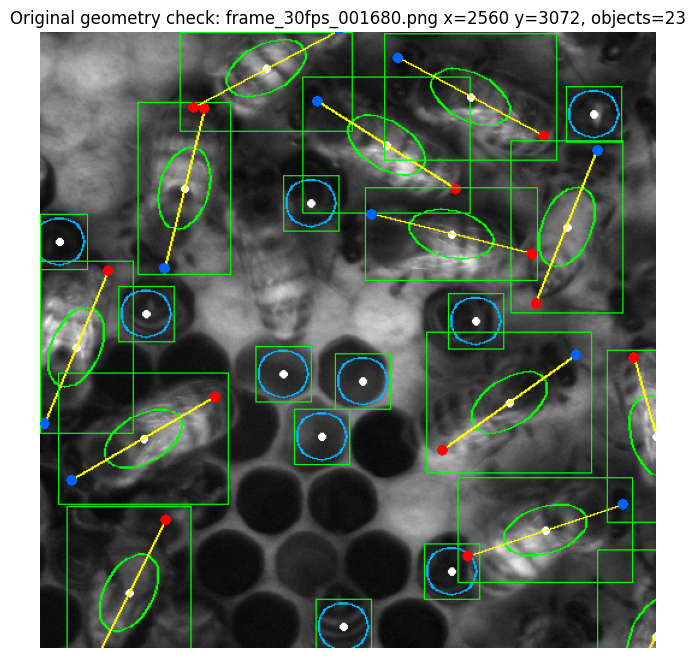

In [6]:

def draw_bbox(draw: ImageDraw.ImageDraw, box, color=BBOX_COLOR, width=2):
    x1, y1, x2, y2 = box
    draw.rectangle([x1, y1, x2, y2], outline=color, width=width)


def draw_axis_points(draw: ImageDraw.ImageDraw, head, tail, width=2):
    hx, hy = head
    tx, ty = tail
    draw.line([tx, ty, hx, hy], fill=AXIS_COLOR, width=width)
    draw.ellipse([hx - 4, hy - 4, hx + 4, hy + 4], fill=HEAD_COLOR)  # blue = head
    draw.ellipse([tx - 4, ty - 4, tx + 4, ty + 4], fill=TAIL_COLOR)  # red = tail


def show_original_notebook_geometry(
    img_path: Path | None = None,
    ann_path: Path | None = None,
    crop_index: int | None = None,
    max_objects: int | None = None,
):
    """
    Visual check before conversion.

    This uses the original dataset geometry:
    offset_x/offset_y are crop origins, x/y are local coordinates inside a 512x512 crop.
    """
    pairs = find_pairs(FRAMES_DIR, ANNOTATIONS_DIR)
    if img_path is None or ann_path is None:
        img_path, ann_path = pairs[1]

    img = Image.open(img_path).convert('RGB')
    ann = read_annotation(ann_path)

    groups = list(ann.groupby(['offset_x', 'offset_y']))
    if not groups:
        raise ValueError(f'No annotation groups found in {ann_path}')

    # By default show the crop with the largest number of objects.
    if crop_index is None:
        crop_index = int(np.argmax([len(g[1]) for g in groups]))

    (offset_x, offset_y), crop_ann = groups[crop_index]
    offset_x = int(offset_x)
    offset_y = int(offset_y)

    crop = img.crop((
        offset_x,
        offset_y,
        offset_x + SOURCE_CROP_SIZE,
        offset_y + SOURCE_CROP_SIZE,
    )).convert('RGB')

    draw = ImageDraw.Draw(crop)

    rows = list(crop_ann.itertuples(index=False))
    if max_objects is not None:
        rows = rows[:max_objects]

    drawn = 0
    for row in rows:
        cx = float(row.x)
        cy = float(row.y)
        source_class = int(row.source_class)
        angle = float(row.angle)

        if not point_inside_crop(cx, cy, SOURCE_CROP_SIZE):
            continue

        # 1) Original ellipse/circle geometry
        if source_class == 1:
            points = make_ellipse_polygon(cx, cy, angle)
            draw.line(points + [points[0]], fill=(0, 255, 0), width=2)
        elif source_class == 2:
            points = make_circle_polygon(cx, cy)
            draw.line(points + [points[0]], fill=(0, 180, 255), width=2)
        else:
            continue

        # 2) Class-aware artificial bbox used for YOLO-Pose
        x1, y1, x2, y2 = bbox_from_source_geometry(cx, cy, angle, source_class)
        x1 = clip(x1, 0, SOURCE_CROP_SIZE)
        y1 = clip(y1, 0, SOURCE_CROP_SIZE)
        x2 = clip(x2, 0, SOURCE_CROP_SIZE)
        y2 = clip(y2, 0, SOURCE_CROP_SIZE)
        draw_bbox(draw, (x1, y1, x2, y2), color=BBOX_COLOR, width=1)

        # 3) Center
        draw.ellipse([cx - 3, cy - 3, cx + 3, cy + 3], fill=CENTER_COLOR)

        # 4) Body-axis keypoints only for full bees.
        # For source_class == 2 the source angle is often not informative, so keypoints are disabled later too.
        if source_class == 1:
            head, tail = head_tail_from_center_angle(cx, cy, angle, source_class)
            draw_axis_points(draw, head, tail, width=2)

        drawn += 1

    print('image:', img_path.name, 'size:', img.size)
    print('annotation:', ann_path.name)
    print('crop offset:', offset_x, offset_y)
    print('crop size:', crop.size)
    print('objects in crop:', len(crop_ann), '| drawn:', drawn)
    print('FULL bbox length/width:',
          2 * ELLIPSE_HALF_LENGTH_PX * FULL_BBOX_LENGTH_SCALE,
          2 * ELLIPSE_HALF_WIDTH_PX * FULL_BBOX_WIDTH_SCALE)
    print('PARTIAL bbox size:', 2 * PARTIAL_CIRCLE_RADIUS_PX * PARTIAL_BBOX_SCALE)
    print('Legend: green/cyan source shape, green bbox, white center, yellow axis, blue=head, red=tail.')
    print('If blue/red are reversed, change HEAD_TAIL_FLIP_RAD between 0 and math.pi and rerun.')

    plt.figure(figsize=(8, 8))
    plt.imshow(crop)
    plt.title(f'Original geometry check: {img_path.name} x={offset_x} y={offset_y}, objects={len(crop_ann)}')
    plt.axis('off')
    plt.show()


if RUN_ORIGINAL_GEOMETRY_CHECK:
    show_original_notebook_geometry()
else:
    print('RUN_ORIGINAL_GEOMETRY_CHECK=False')


### Решение после проверки

Если в предыдущей ячейке:

- овалы стоят на пчёлах;
- bbox для целых пчёл покрывает тело без чрезмерного запаса;
- bbox для частичных/круглых объектов не слишком раздут;
- жёлтая линия идёт вдоль длинной оси тела;
- синяя точка стоит на голове, красная — на хвосте;

то поставь:

```python
ORIGINAL_GEOMETRY_APPROVED = True
```

Если bbox для целых или частичных объектов неудачный, меняй:

```python
FULL_BBOX_LENGTH_SCALE
FULL_BBOX_WIDTH_SCALE
PARTIAL_BBOX_SCALE
```

Если синий/красный конец оси поменялись местами, поменяй:

```python
HEAD_TAIL_FLIP_RAD = 0.0  # или math.pi
```


In [7]:
# После визуальной проверки предыдущей ячейки поставьте True.
ORIGINAL_GEOMETRY_APPROVED = True


## 4. Конвертер в YOLO-Pose

Эта версия не делает sliding-window `640/480`.

Рабочая геометрия:

```text
offset_x, offset_y из txt → crop 512×512 → local_x/local_y остаются локальными
```

Для каждой пчелы создаём YOLO-Pose label:

```text
class bbox_x bbox_y bbox_w bbox_h axis_p1_x axis_p1_y v axis_p2_x axis_p2_y v
```

В коде точки всё ещё называются `head/tail`, но методологически это лучше понимать как **два конца продольной оси тела**.


In [8]:

def yolo_pose_line_from_source_row(row, crop_size: int = SOURCE_CROP_SIZE) -> str | None:
    cx = float(row.x)
    cy = float(row.y)
    source_class = int(row.source_class)
    angle = float(row.angle)

    if not point_inside_crop(cx, cy, crop_size):
        return None

    # source_class == 2: partial/round object.
    # Bbox is used, but keypoints are disabled because orientation is not reliable.
    partial = source_class == 2

    x1, y1, x2, y2 = bbox_from_source_geometry(cx, cy, angle, source_class)
    x1 = clip(x1, 0, crop_size)
    y1 = clip(y1, 0, crop_size)
    x2 = clip(x2, 0, crop_size)
    y2 = clip(y2, 0, crop_size)

    bw = max(1.0, x2 - x1)
    bh = max(1.0, y2 - y1)
    bx = (x1 + x2) / 2
    by = (y1 + y2) / 2

    head, tail = head_tail_from_center_angle(cx, cy, angle, source_class)

    def kpt(pt, visible_default: int):
        x, y = pt
        if visible_default == 0:
            return 0.0, 0.0, 0
        if point_inside_crop(x, y, crop_size):
            return x, y, visible_default
        return 0.0, 0.0, 0

    hv_default = 0 if partial else 2

    hx, hy, hv = kpt(head, hv_default)
    tx, ty, tv = kpt(tail, hv_default)

    values = [
        0,
        bx / crop_size, by / crop_size, bw / crop_size, bh / crop_size,
        hx / crop_size, hy / crop_size, hv,
        tx / crop_size, ty / crop_size, tv,
    ]
    return ' '.join(str(v) if isinstance(v, int) else f'{v:.6f}' for v in values)


@dataclass
class OriginalGeometryPoseConverter:
    frames_dir: Path
    annotations_dir: Path
    output_dir: Path
    source_crop_size: int = SOURCE_CROP_SIZE
    seed: int = SEED
    keep_empty_crops: bool = False

    def find_pairs(self):
        return find_pairs(self.frames_dir, self.annotations_dir)

    def _prepare_dirs(self):
        if self.output_dir.exists():
            shutil.rmtree(self.output_dir)
        for split in ['train', 'val', 'test']:
            (self.output_dir / 'images' / split).mkdir(parents=True, exist_ok=True)
            (self.output_dir / 'labels' / split).mkdir(parents=True, exist_ok=True)

    def _split_pairs(self, pairs, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO):
        rng = random.Random(self.seed)
        pairs = pairs[:]
        rng.shuffle(pairs)
        n = len(pairs)
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))
        return {
            'train': pairs[:train_end],
            'val': pairs[train_end:val_end],
            'test': pairs[val_end:],
        }

    def process_pair(self, img_path: Path, ann_path: Path, split: str):
        img = Image.open(img_path).convert('RGB')
        ann = read_annotation(ann_path)

        crops_created = 0
        objects_created = 0
        skipped_oob = 0

        for (offset_x, offset_y), crop_ann in ann.groupby(['offset_x', 'offset_y']):
            offset_x = int(offset_x)
            offset_y = int(offset_y)

            crop = img.crop((
                offset_x,
                offset_y,
                offset_x + self.source_crop_size,
                offset_y + self.source_crop_size,
            )).convert('RGB')

            if crop.size != (self.source_crop_size, self.source_crop_size):
                continue

            yolo_lines = []
            for row in crop_ann.itertuples(index=False):
                line = yolo_pose_line_from_source_row(row, crop_size=self.source_crop_size)
                if line is None:
                    skipped_oob += 1
                    continue
                yolo_lines.append(line)

            if not yolo_lines and not self.keep_empty_crops:
                continue

            crop_name = f'{img_path.stem}__x{offset_x}_y{offset_y}'
            crop.save(self.output_dir / 'images' / split / f'{crop_name}.png')
            (self.output_dir / 'labels' / split / f'{crop_name}.txt').write_text('\n'.join(yolo_lines))

            crops_created += 1
            objects_created += len(yolo_lines)

        return crops_created, objects_created, skipped_oob

    def convert(self, max_frames: int | None = MAX_FRAMES):
        pairs = self.find_pairs()
        if max_frames is not None:
            pairs = pairs[:max_frames]

        self._prepare_dirs()
        splits = self._split_pairs(pairs)
        summary = {}

        for split, split_pairs in splits.items():
            split_crops = 0
            split_objects = 0
            split_skipped = 0
            for img_path, ann_path in tqdm(split_pairs, desc=f'convert {split}'):
                c, o, s = self.process_pair(img_path, ann_path, split)
                split_crops += c
                split_objects += o
                split_skipped += s
            summary[split] = {
                'images': split_crops,
                'objects': split_objects,
                'skipped_oob': split_skipped,
            }

        self.write_yaml()
        return summary

    def write_yaml(self):
        data = {
            'path': str(self.output_dir),
            'train': 'images/train',
            'val': 'images/val',
            'test': 'images/test',
            'kpt_shape': [2, 3],
            # head/tail are not left/right symmetric; horizontal flips are disabled during training.
            'flip_idx': [0, 1],
            'names': {0: 'bee'},
        }
        (self.output_dir / 'data.yaml').write_text(yaml.safe_dump(data, sort_keys=False, allow_unicode=True))


## 5. Конвертация датасета

Защита: конвертация не стартует, пока `ORIGINAL_GEOMETRY_APPROVED=False`.


In [9]:
converter = OriginalGeometryPoseConverter(
    frames_dir=FRAMES_DIR,
    annotations_dir=ANNOTATIONS_DIR,
    output_dir=YOLO_DATASET_DIR,
    source_crop_size=SOURCE_CROP_SIZE,
)

if PREPARE_DATASET:
    if not ORIGINAL_GEOMETRY_APPROVED:
        raise RuntimeError(
            'Сначала проверь ячейку original geometry check. '
            'Если метки стоят правильно, поставь ORIGINAL_GEOMETRY_APPROVED=True и запусти конвертацию снова.'
        )
    summary = converter.convert(max_frames=MAX_FRAMES)
    print(summary)
else:
    print('PREPARE_DATASET=False, используем существующий датасет:', YOLO_DATASET_DIR)


PREPARE_DATASET=False, используем существующий датасет: /content/drive/MyDrive/ITMO_NN_2/yolo_bees_pose_dataset


## 6. Проверка собранного YOLO-Pose датасета

Эта визуализация читает уже готовые YOLO-Pose `.txt` и рисует:

- зелёный bbox;
- синюю точку головы;
- красную точку хвоста;
- жёлтую линию между ними.

Для `source_class == 2` keypoints отключаются, поэтому после конвертации у частичных/круглых объектов должен остаться bbox без оси тела.


image: frame_30fps_001680__x1024_y3072.png size: (512, 512) objects: 18


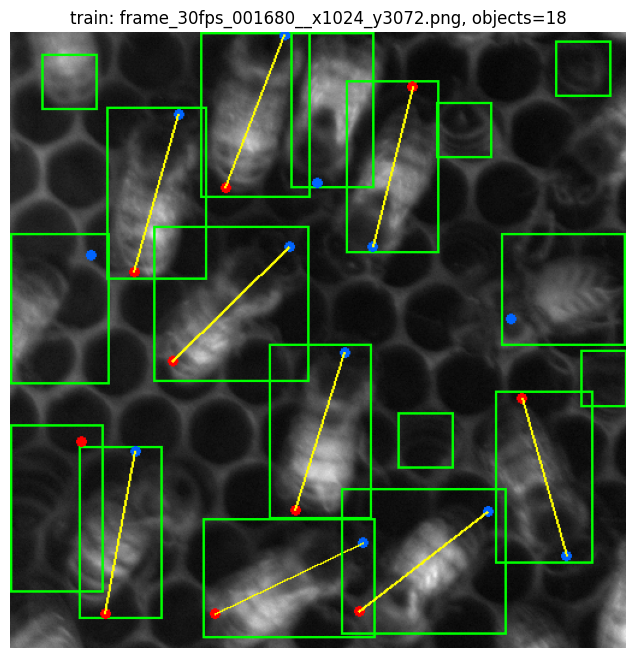

In [10]:
def show_pose_label_sample(split_name='train', index=0):
    img_paths = sorted((YOLO_DATASET_DIR / 'images' / split_name).glob('*.png'))
    if not img_paths:
        raise FileNotFoundError(f'Нет изображений в {YOLO_DATASET_DIR / "images" / split_name}')

    img_path = img_paths[index]
    label_path = YOLO_DATASET_DIR / 'labels' / split_name / f'{img_path.stem}.txt'

    img = Image.open(img_path).convert('RGB')
    w_img, h_img = img.size
    draw = ImageDraw.Draw(img)

    lines = []
    if label_path.exists():
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]

    for line in lines:
        p = line.split()
        bx = float(p[1]) * w_img
        by = float(p[2]) * h_img
        bw = float(p[3]) * w_img
        bh = float(p[4]) * h_img
        x1, y1 = bx - bw / 2, by - bh / 2
        x2, y2 = bx + bw / 2, by + bh / 2
        draw.rectangle([x1, y1, x2, y2], outline=BBOX_COLOR, width=2)

        hx = float(p[5]) * w_img
        hy = float(p[6]) * h_img
        hv = int(float(p[7]))
        tx = float(p[8]) * w_img
        ty = float(p[9]) * h_img
        tv = int(float(p[10]))

        if hv > 0:
            draw.ellipse([hx - 4, hy - 4, hx + 4, hy + 4], fill=HEAD_COLOR)
        if tv > 0:
            draw.ellipse([tx - 4, ty - 4, tx + 4, ty + 4], fill=TAIL_COLOR)
        if hv > 0 and tv > 0:
            draw.line([tx, ty, hx, hy], fill=AXIS_COLOR, width=2)

    print('image:', img_path.name, 'size:', img.size, 'objects:', len(lines))
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f'{split_name}: {img_path.name}, objects={len(lines)}')
    plt.axis('off')
    plt.show()

show_pose_label_sample('train', 2)


## 7. Обучение YOLO-Pose

Crop-ы физически `512×512`, но `imgsz=640`. Это нормально: Ultralytics ресайзит изображение и labels согласованно внутри train pipeline.


In [11]:
if TRAIN_MODEL:
    # После пересборки labels лучше удалить cache, чтобы YOLO не использовал старые индексы.
    for cache_path in YOLO_DATASET_DIR.glob('**/*.cache'):
        cache_path.unlink(missing_ok=True)

    model = YOLO('yolo11n-pose.pt')
    results = model.train(
        data=str(DATA_YAML),
        task='pose',
        epochs=5,
        imgsz=YOLO_IMGSZ,
        batch=32,
        workers=4,
        patience=15,
        device=DEVICE,
        fliplr=0.0,  # важно: не отражаем, чтобы не путать head/tail на первом baseline
        project=str(PROJECT_DIR / 'runs'),
        name=RUN_NAME,
        exist_ok=True
    )
else:
    print('TRAIN_MODEL=False')


Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ITMO_NN_2/yolo_bees_pose_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_pose_bees_original_512_to_imgsz640_class_bbox_v3, nbs=64, nms

## 8. Графики обучения


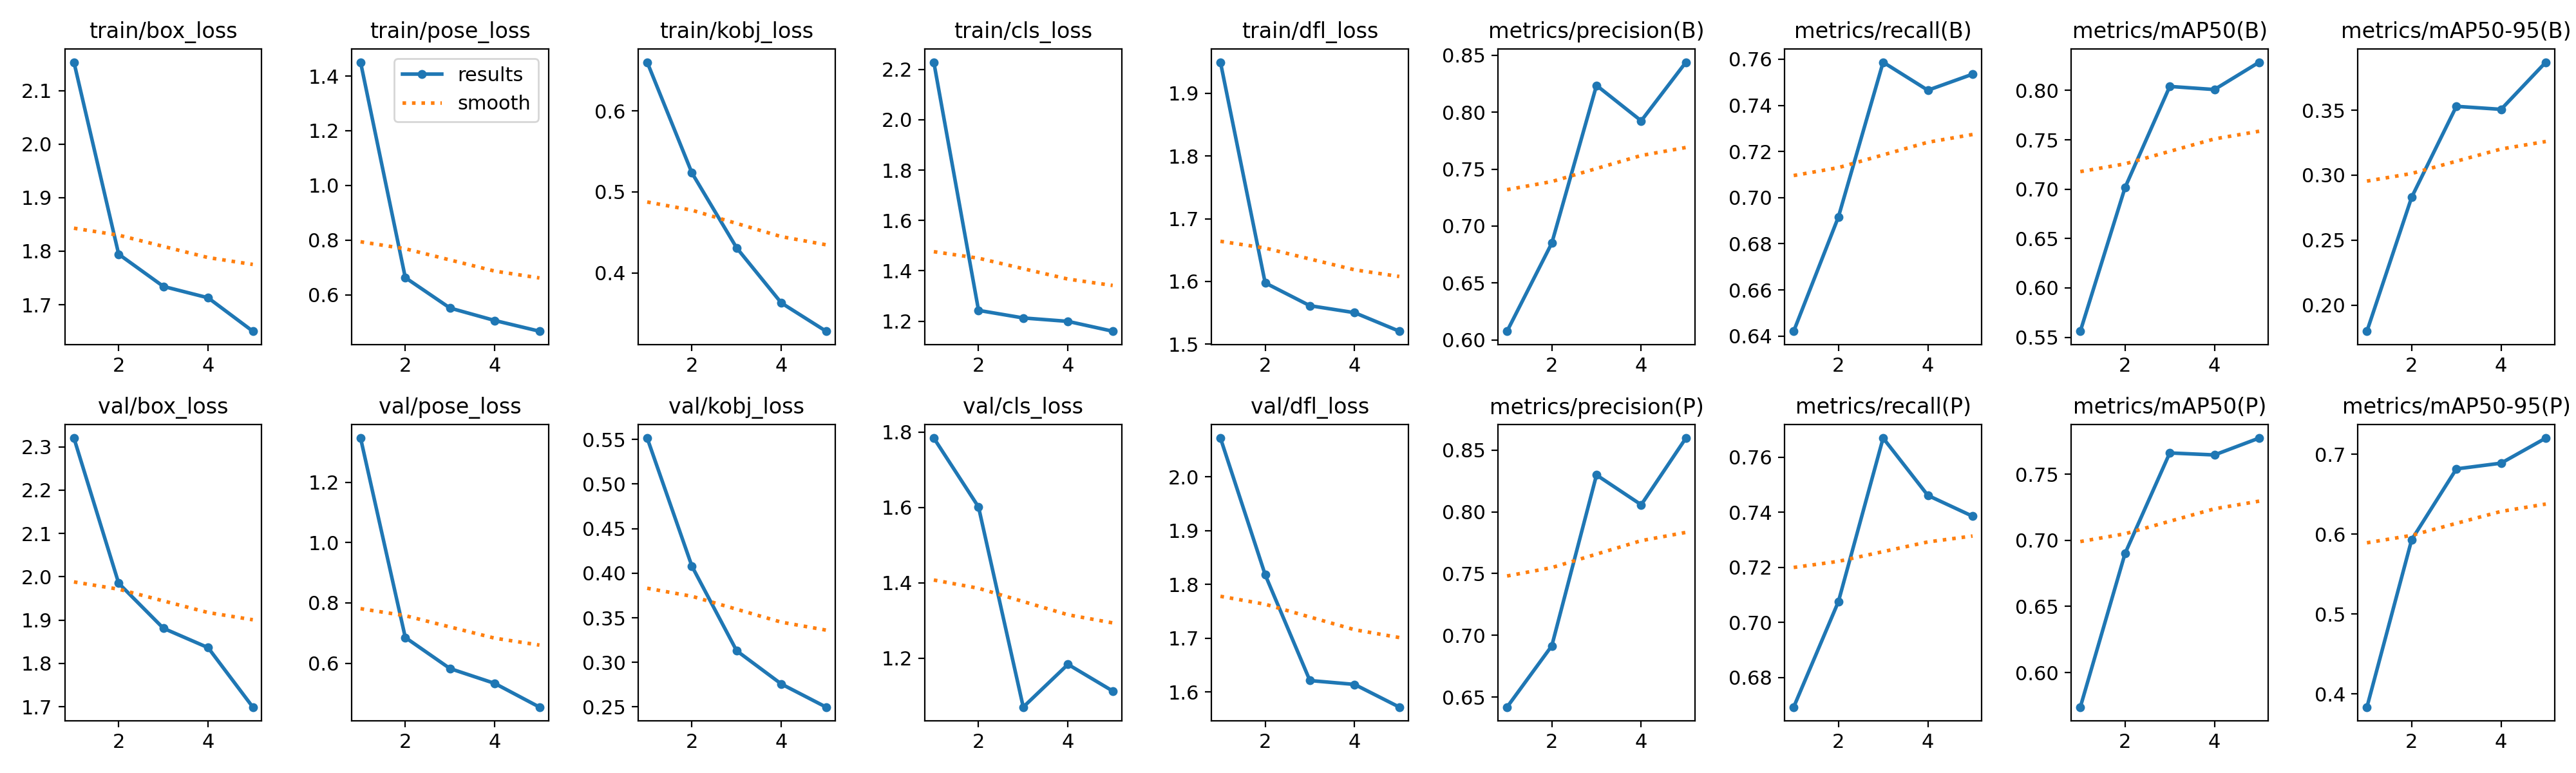

,epoch,time,train/box_loss,train/pose_loss,train/kobj_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,metrics/mAP50(P),metrics/mAP50-95(P),val/box_loss,val/pose_loss,val/kobj_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,99.4631,2.15320,1.45061,0.66023,2.22838,1.94966,0.60755,0.64208,0.55612,...,0.57385,0.38367,2.32009,1.34636,0.55148,1.78403,2.07222,0.000655,0.000655,0.000655
1,2,151.0300,1.79442,0.66299,0.52349,1.24313,1.59775,0.68496,0.69162,0.70161,...,0.69004,0.59313,1.98514,0.68558,0.40787,1.60113,1.81818,0.001060,0.001060,0.001060
2,3,200.1130,1.73416,0.55167,0.43091,1.21305,1.56133,0.82363,0.75872,0.80407,...,0.76613,0.68182,1.88123,0.58252,0.31303,1.07034,1.62133,0.001201,0.001201,0.001201
3,4,250.3980,1.71289,0.50619,0.36283,1.19950,1.55020,0.79247,0.74656,0.80092,...,0.76462,0.68902,1.83650,0.53339,0.27575,1.18372,1.61409,0.000812,0.000812,0.000812
4,5,301.8850,1.65044,0.46696,0.32790,1.16042,1.52063,0.84402,0.75351,0.82862,...,0.77739,0.72043,1.69938,0.45487,0.24987,1.11297,1.57196,0.000416,0.000416,0.000416


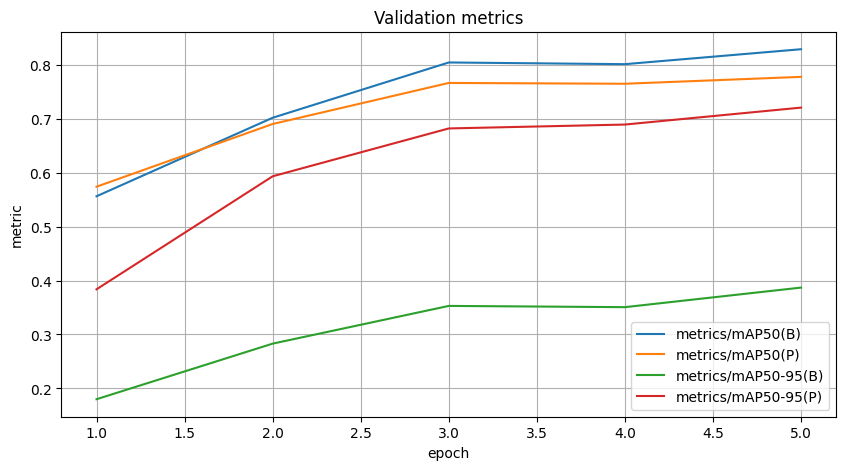

In [14]:
run_dir = PROJECT_DIR / 'runs' / RUN_NAME
results_png = run_dir / 'results.png'
results_csv = run_dir / 'results.csv'

if results_png.exists():
    display(IPyImage(filename=str(results_png)))
else:
    print('results.png пока не найден:', results_png)

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    display(df.tail())

    cols = [c for c in ['metrics/mAP50(B)', 'metrics/mAP50(P)', 'metrics/mAP50-95(B)', 'metrics/mAP50-95(P)'] if c in df.columns]
    if cols:
        plt.figure(figsize=(10, 5))
        for c in cols:
            plt.plot(df['epoch'], df[c], label=c)
        plt.xlabel('epoch')
        plt.ylabel('metric')
        plt.title('Validation metrics')
        plt.legend()
        plt.grid(True)
        plt.show()
else:
    print('results.csv пока не найден:', results_csv)


## 9. Предсказания на test crop-ах


In [13]:
if RUN_TEST_PREDICT:
    best_model_path = PROJECT_DIR / 'runs' / RUN_NAME / 'weights' / 'best.pt'
    test_images_dir = YOLO_DATASET_DIR / 'images' / 'test'

    if not best_model_path.exists():
        print('Модель ещё не обучена:', best_model_path)
    elif not test_images_dir.exists():
        print('Нет test images:', test_images_dir)
    else:
        model = YOLO(str(best_model_path))
        pred_results = model.predict(
            source=str(test_images_dir),
            imgsz=YOLO_IMGSZ,
            conf=0.25,
            iou=0.4,
            max_det=1000,
            device=DEVICE,
            save=True,
            project=str(PROJECT_DIR / 'runs'),
            name=f'predictions_{RUN_NAME}',
            exist_ok=True,
        )
else:
    print('RUN_TEST_PREDICT=False')



image 1/396 /content/drive/MyDrive/ITMO_NN_2/yolo_bees_pose_dataset/images/test/frame_30fps_001800__x1024_y2048.png: 640x640 7 bees, 9.7ms
image 2/396 /content/drive/MyDrive/ITMO_NN_2/yolo_bees_pose_dataset/images/test/frame_30fps_001800__x1024_y2560.png: 640x640 13 bees, 10.5ms
image 3/396 /content/drive/MyDrive/ITMO_NN_2/yolo_bees_pose_dataset/images/test/frame_30fps_001800__x1024_y3072.png: 640x640 16 bees, 10.1ms
image 4/396 /content/drive/MyDrive/ITMO_NN_2/yolo_bees_pose_dataset/images/test/frame_30fps_001800__x1024_y3584.png: 640x640 15 bees, 111.6ms
image 5/396 /content/drive/MyDrive/ITMO_NN_2/yolo_bees_pose_dataset/images/test/frame_30fps_001800__x1536_y2048.png: 640x640 19 bees, 10.0ms
image 6/396 /content/drive/MyDrive/ITMO_NN_2/yolo_bees_pose_dataset/images/test/frame_30fps_001800__x1536_y2560.png: 640x640 17 bees, 10.5ms
image 7/396 /content/drive/MyDrive/ITMO_NN_2/yolo_bees_pose_dataset/images/test/frame_30fps_001800__x1536_y3072.png: 640x640 21 bees, 9.5ms
image 8/396 /c

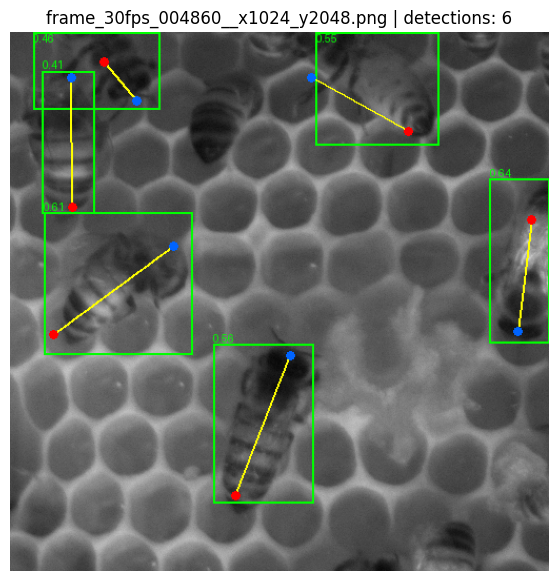

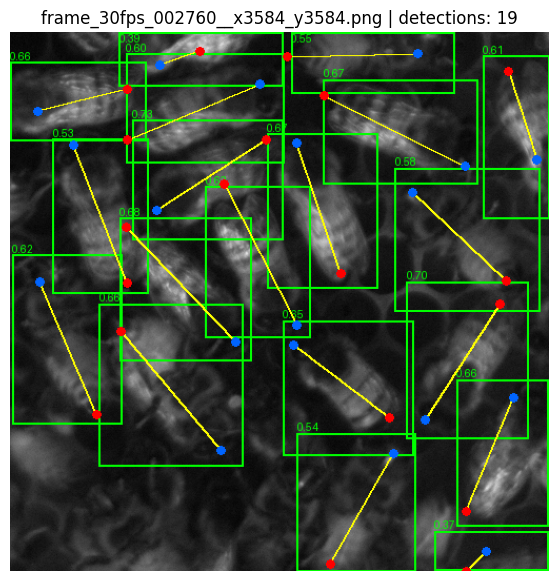

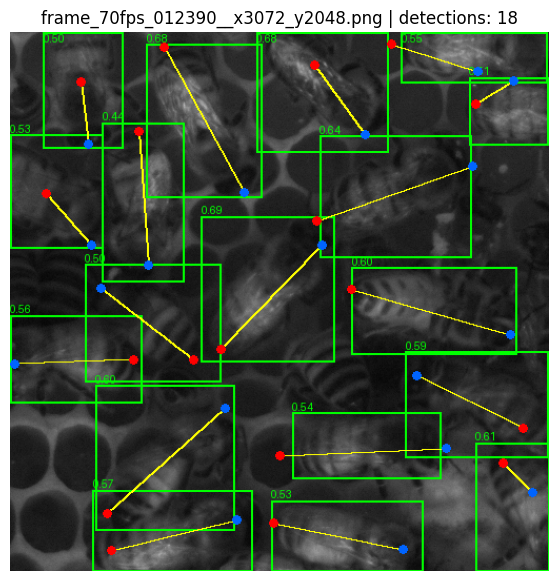

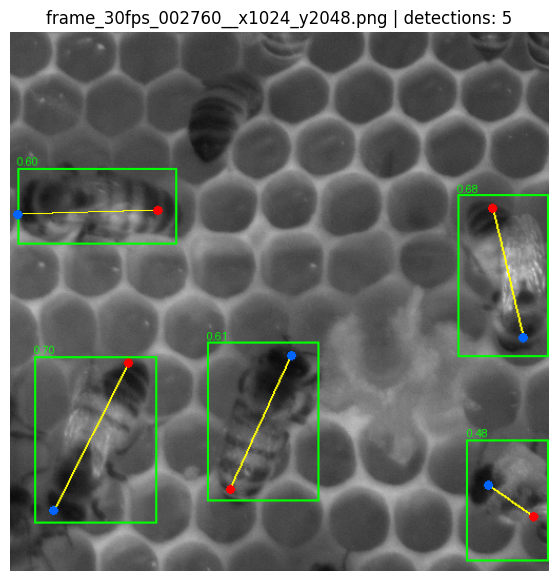

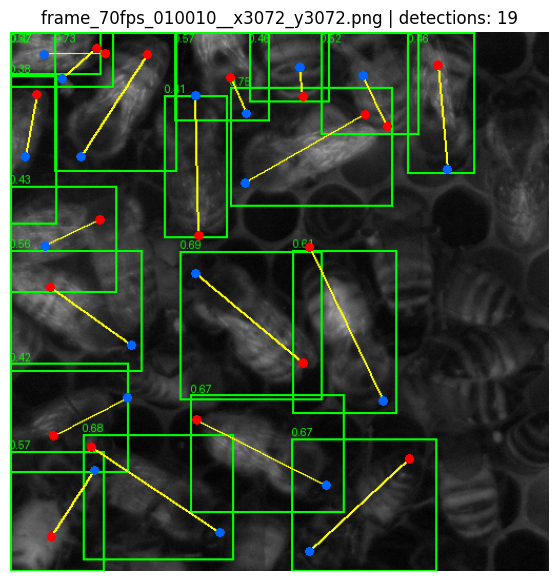

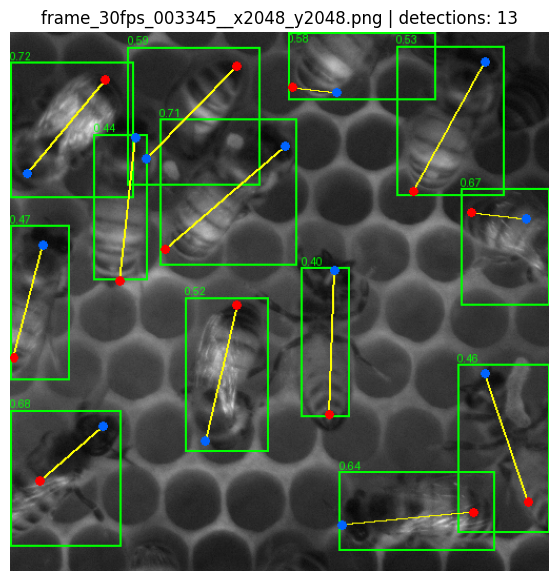

In [16]:
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import random
from ultralytics import YOLO

best_model_path = PROJECT_DIR / "runs" / RUN_NAME / "weights" / "best.pt"
test_images_dir = YOLO_DATASET_DIR / "images" / "test"

assert best_model_path.exists(), f"Не найден best.pt: {best_model_path}"
assert test_images_dir.exists(), f"Не найдена test-папка: {test_images_dir}"

model = YOLO(str(best_model_path))

test_images = sorted(test_images_dir.glob("*.png"))
sample_images = random.sample(test_images, k=min(6, len(test_images)))

results = model.predict(
    source=[str(p) for p in sample_images],
    imgsz=YOLO_IMGSZ,
    conf=0.35,
    device=DEVICE,
    save=False,
    verbose=False,
)

for img_path, r in zip(sample_images, results):
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    # bbox
    if r.boxes is not None:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = float(box.conf[0].cpu().numpy())

            draw.rectangle([x1, y1, x2, y2], outline=(0, 255, 0), width=2)
            draw.text((x1, max(0, y1 - 12)), f"{conf:.2f}", fill=(0, 255, 0))

    # keypoints: blue=head, red=tail
    if r.keypoints is not None and r.keypoints.xy is not None:
        kpts = r.keypoints.xy.cpu().numpy()

        for obj_kpts in kpts:
            if len(obj_kpts) < 2:
                continue

            head_x, head_y = obj_kpts[0]
            tail_x, tail_y = obj_kpts[1]

            draw.line([tail_x, tail_y, head_x, head_y], fill=(255, 255, 0), width=2)
            draw.ellipse([head_x - 4, head_y - 4, head_x + 4, head_y + 4], fill=(0, 100, 255))
            draw.ellipse([tail_x - 4, tail_y - 4, tail_x + 4, tail_y + 4], fill=(255, 0, 0))

    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.title(f"{img_path.name} | detections: {0 if r.boxes is None else len(r.boxes)}")
    plt.axis("off")
    plt.show()

## 10. Что делать дальше

1. Сначала добиваемся, чтобы `show_original_notebook_geometry()` показывал корректные метки.
2. Потом проверяем `show_pose_label_sample()`.
3. Только после этого обучаем модель.
4. Если всё работает на исходной геометрии `512→imgsz640`, можно отдельно возвращаться к эксперименту `crop_size=640, stride=480`, но уже как к новой задаче преобразования координат, а не как к простой замене размера crop-а.


## Конспект текущего решения

1. **Baseline строится в авторской геометрии датасета.**  
   Используем crop-ы `512×512` по `offset_x/offset_y` из `.txt`.

2. **Не используем sliding-window `640/480` на этом этапе.**  
   Эта схема полезна для будущего inference на больших кадрах, но она усложнила геометрию и привела к сдвигам.

3. **Исходная разметка — это не bbox.**  
   В `.txt` есть центр пчелы, тип объекта и угол ориентации. Bbox мы создаём сами.

4. **Для bbox теперь есть разные параметры для целых и частичных пчёл.**  
   Целые пчёлы получают вытянутый bbox через `FULL_BBOX_LENGTH_SCALE` и `FULL_BBOX_WIDTH_SCALE`; частичные/круглые объекты получают компактный квадратный bbox через `PARTIAL_BBOX_SCALE`.

5. **YOLO-Pose выбран как baseline для bbox + ориентации.**  
   Две keypoint-точки задают продольную ось тела. Для `source_class == 2` keypoints отключены.

6. **Ориентация исправлена через `angle + pi/2`.**  
   Это нужно потому, что длинная ось эллипса в исходной формуле направлена вдоль `Y`.

7. **Цвета зафиксированы как переменные.**  
   Синяя точка — голова (`HEAD_COLOR`), красная — хвост (`TAIL_COLOR`). Сейчас стоит `HEAD_TAIL_FLIP_RAD = math.pi`.

8. **`YOLO_IMGSZ = 640` не требует физического crop-а 640×640.**  
   Можно обучать YOLO на crop-ах 512×512, а Ultralytics сам выполнит корректный resize.

9. **Перед полной конвертацией обязательна визуальная проверка.**  
   Сначала проверяем `show_original_notebook_geometry()`, потом ставим `ORIGINAL_GEOMETRY_APPROVED=True`.
